In [6]:
from scripts.train_vbe_kfold import train_vbe
import torch
import matplotlib.pyplot as plt
from torch import Tensor
from sklearn.decomposition import PCA

In [2]:
t = torch.rand(100) * 4 * torch.pi
data = torch.stack([t, t.sin()], dim=-1)
dmat_sqr = (data[:, None] - data).square().sum(-1)
dmat_sqr /= dmat_sqr.max()
dmat_sqr += 1e-3 # for numerical stability of the algorithm
vbe = train_vbe(dmat_sqr, "sine", epochs=500)

100%|██████████| 500/500 [02:30<00:00,  3.32it/s]


In [3]:
relevance = sorted(vbe.relevance_score(), reverse=True)[:10]
embedding = vbe.embed(dmat_sqr.to(vbe.device))

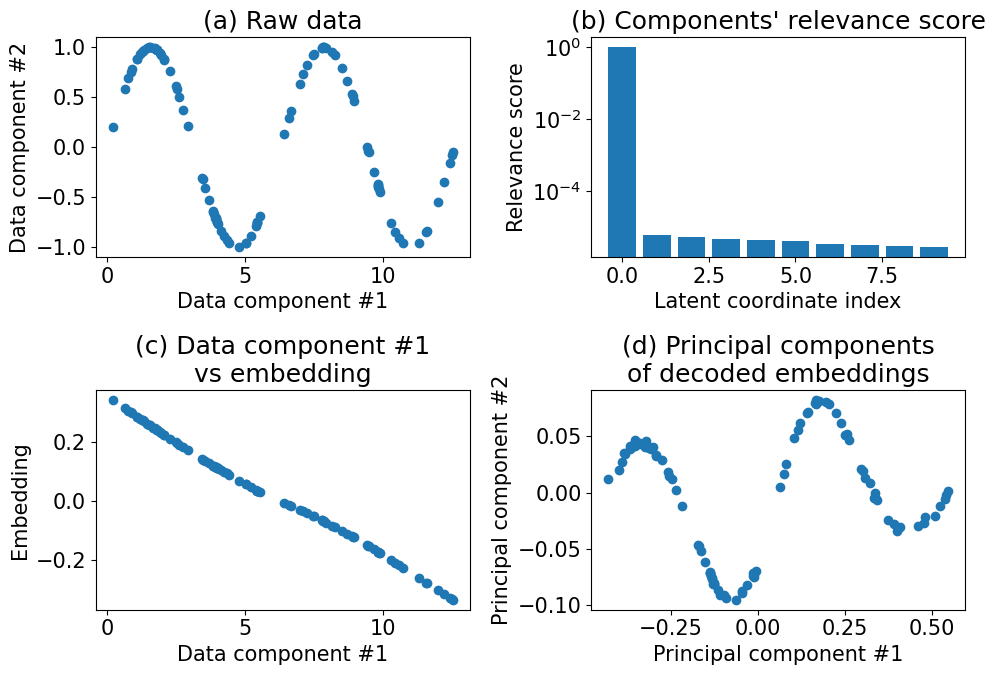

In [14]:
plt.rcParams["font.size"] = 15
plt.figure(figsize=(10, 7))


plt.subplot(2, 2, 1)
plt.scatter(*data.T)
plt.xlabel("Data component #1")
plt.ylabel("Data component #2")
plt.title("(a) Raw data")


plt.subplot(2, 2, 2)
plt.bar(range(len(relevance)), relevance)
plt.xlabel("Latent coordinate index")
plt.ylabel("Relevance score")
plt.yscale("log")
plt.title(f"(b) Components' relevance score")


plt.subplot(2, 2, 3)
plt.scatter(t, embedding[:, 0])
plt.xlabel("Data component #1")
plt.ylabel("Embedding")
plt.title("(c) Data component #1\nvs embedding")


plt.subplot(2, 2, 4)
plt.scatter(*PCA(n_components=2).fit_transform(vbe(dmat_sqr.to(vbe.device)).detach().cpu()).T)
plt.xlabel("Principal component #1")
plt.ylabel("Principal component #2")
plt.title("(d) Principal components\nof decoded embeddings")


plt.tight_layout()
plt.savefig("sine_graphs.pdf")
plt.show()